In [35]:
import numpy as np
import matplotlib.pyplot as plt
import lenstronomy
from lenstronomy.SimulationAPI.sim_api import SimAPI
import time
import pandas as pd
from astropy.cosmology import Planck18 as cosmo
import astropy.units as u
import os 
from astropy.convolution import Gaussian2DKernel, Moffat2DKernel, convolve

In [36]:
def apply_astropy_psf(image, seeing_fwhm_pix, profile='gaussian'):
    # 1. Create the kernel
    if profile == 'gaussian':
        sigma = seeing_fwhm_pix / 2.35482
        kernel = Gaussian2DKernel(x_stddev=sigma)
    elif profile == 'moffat':
        # beta=4.76 is standard for atmospheric seeing
        alpha = seeing_fwhm_pix / (2 * np.sqrt(2**(1/4.76) - 1))
        kernel = Moffat2DKernel(gamma=alpha, alpha=4.76)
    
    # 2. Convolve the image with the telescope/atmosphere kernel
    # boundary='wrap' or 'extend' handles the edges of the image smoothly
    blurred_image = convolve(image, kernel, boundary='extend')
    return blurred_image

In [37]:
def make_lens_image(seed=None, redshift_range=(0.3, 2.0)):
    if seed is not None:
        np.random.seed(seed)

    theta_E = np.random.uniform(1.0, 2.0)
    source_offset = np.random.uniform(0.05, 0.2)
    source_redshift = np.random.uniform(*redshift_range)
    
    # Physical link: redshift determines source brightness/size
    base_mag = 20.0
    source_mag = base_mag + 1.5 * source_redshift  # dimmer at higher z
    # earlier line: source_size = 0.3 / (1 + 0.5 * source_redshift)  # more compact at higher z 
    # Physical link: redshift determines source brightness/size
    base_mag = 20.0
    source_mag = base_mag + 1.5 * source_redshift  # dimmer at higher z

    # Physically motivated size: fix a real-world source size (kpc), then
    #  convert to an angular size using the true angular diameter distance
    # at this redshift. Replaces the old 0.3/(1+0.5*z) formula, which shrinks
    # forever and never reflects the real D_A turnover near z~1.6.
    R_kpc = 1.0  # typical compact source size (order of the SLACS median)
    D_A_kpc = cosmo.angular_diameter_distance(source_redshift).to(u.kpc).value
    source_size = (R_kpc / D_A_kpc) * (180 / np.pi) * 3600  # arcsec
    
    lens_mag = np.random.uniform(20.0, 21.5)

    kwargs_single_band = {
        'pixel_scale': 0.263, 'exposure_time': 90,
        'magnitude_zero_point': 27.0, 'read_noise': 7,
        'ccd_gain': 6.083, 'sky_brightness': 23.5,
        'seeing': 0.9, 'num_exposures': 1, 'psf_type': 'GAUSSIAN'
    }
    kwargs_model = {
        'lens_model_list': ['SIE'],
        'source_light_model_list': ['SERSIC_ELLIPSE'],
        'lens_light_model_list': ['SERSIC_ELLIPSE']
    }

    sim = SimAPI(64, kwargs_single_band, kwargs_model)

    kwargs_lens_light_mag = [{'magnitude': lens_mag, 'R_sersic': 1.0,
                               'n_sersic': 4.0, 'e1': 0.1, 'e2': -0.1,
                               'center_x': 0.0, 'center_y': 0.0}]
    kwargs_source_mag = [{'magnitude': source_mag, 'R_sersic': source_size,
                           'n_sersic': 2.0, 'e1': 0.1, 'e2': -0.1,
                           'center_x': source_offset, 'center_y': source_offset}]
    kwargs_lens = [{'theta_E': theta_E, 'e1': 0.1, 'e2': -0.1,
                    'center_x': 0.0, 'center_y': 0.0}]

    kwargs_lens_light, kwargs_source, _ = sim.magnitude2amplitude(
        kwargs_lens_light_mag=kwargs_lens_light_mag,
        kwargs_source_mag=kwargs_source_mag)

    image_model = sim.image_model_class({'supersampling_factor': 1})
    image = image_model.image(kwargs_lens=kwargs_lens, kwargs_source=kwargs_source,
                               kwargs_lens_light=kwargs_lens_light)
    noise = sim.noise_for_model(model=image, background_noise=True, poisson_noise=True)
    return image + noise, source_redshift



def make_non_lens_image(seed=None):
    """Just a galaxy with no lensing — source offset so far it doesn't lens"""
    if seed is not None:
        np.random.seed(seed)

    kwargs_single_band = {
        'pixel_scale': 0.263,
        'exposure_time': 90,
        'magnitude_zero_point': 27.0,
        'read_noise': 7,
        'ccd_gain': 6.083,
        'sky_brightness': 23.5,
        'seeing': 0.9,
        'num_exposures': 1,
        'psf_type': 'GAUSSIAN'
    }

    kwargs_model = {
        'lens_model_list': ['SIE'],
        'source_light_model_list': ['SERSIC_ELLIPSE'],
        'lens_light_model_list': ['SERSIC_ELLIPSE']
    }

    sim = SimAPI(64, kwargs_single_band, kwargs_model)

    kwargs_lens_light_mag = [{'magnitude': 19.5,
                               'R_sersic': 1.0,
                               'n_sersic': 4.0,
                               'e1': 0.1, 'e2': -0.1,
                               'center_x': 0.0, 'center_y': 0.0}]

    # Source far off-axis so no visible lensing
    kwargs_source_mag = [{'magnitude': 22.0,
                           'R_sersic': 0.3,
                           'n_sersic': 2.0,
                           'e1': 0.1, 'e2': -0.1,
                           'center_x': 5.0,
                           'center_y': 5.0}]

    kwargs_lens = [{'theta_E': 0.01,  # negligible mass
                    'e1': 0.0, 'e2': 0.0,
                    'center_x': 0.0, 'center_y': 0.0}]

    kwargs_lens_light, kwargs_source, _ = sim.magnitude2amplitude(
        kwargs_lens_light_mag=kwargs_lens_light_mag,
        kwargs_source_mag=kwargs_source_mag
    )

    image_model = sim.image_model_class({'supersampling_factor': 1})
    image = image_model.image(
        kwargs_lens=kwargs_lens,
        kwargs_source=kwargs_source,
        kwargs_lens_light=kwargs_lens_light
    )

    noise = sim.noise_for_model(model=image, background_noise=True, poisson_noise=True)
    return image + noise 



In [38]:
redshift_train_range = (0.2, 0.6)  # only low-z lenses in training set for now
redshift_test_range = (0.2, 2.0)  # only high-z lenses in test set for now
redshift_validation_range = (0.2, 2.0)  # only high-z lenses in validation set for now

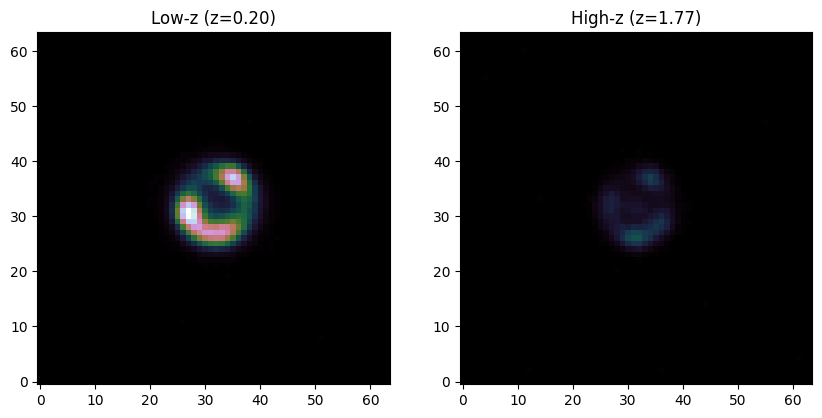

In [39]:
# Low-z example
img_low, z_low = make_lens_image(seed=1, redshift_range=(0.2, 0.4))
# High-z example  
img_high, z_high = make_lens_image(seed=2, redshift_range=(1.5, 2.0))


vmin, vmax = 0, max(img_low.max(), img_high.max())
fig, axes = plt.subplots(1, 2, figsize=(10,5))
axes[0].imshow(img_low, cmap='cubehelix', origin='lower', vmin=vmin, vmax=vmax)
axes[0].set_title(f'Low-z (z={z_low:.2f})')
axes[1].imshow(img_high, cmap='cubehelix', origin='lower', vmin=vmin, vmax=vmax)
axes[1].set_title(f'High-z (z={z_high:.2f})')
plt.show()

In [40]:
print(f"Low-z max pixel value: {img_low.max():.2f}")
print(f"High-z max pixel value: {img_high.max():.2f}")
print(f"Low-z mean pixel value: {img_low.mean():.4f}")
print(f"High-z mean pixel value: {img_high.mean():.4f}")

Low-z max pixel value: 63.46
High-z max pixel value: 15.70
Low-z mean pixel value: 1.2784
High-z mean pixel value: 0.3206


Generated z=0.44


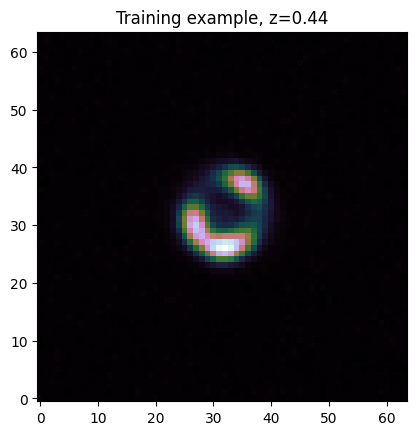

In [41]:
img, z = make_lens_image(seed=0, redshift_range = redshift_train_range)
print(f"Generated z={z:.2f}")
plt.imshow(img, cmap='cubehelix', origin='lower')
plt.title(f"Training example, z={z:.2f}")
plt.show()

In [42]:
pixel_scale = 0.05

In [43]:
# Generate dataset
SAVE_DIR = 'lens_project'
os.makedirs(f'{SAVE_DIR}/testing_images', exist_ok=True)
N = 500  # 500 lens + 500 non-lens
metadata = []
print("Generating lens images...")
for i in range(N//2):
    source_redshift = np.random.uniform(0.3, 2.0)  # random redshift — save but don't use yet
    #img, source_redshift = make_lens_image(seed=i)
    img, source_redshift = make_lens_image(seed=i , redshift_range= redshift_test_range)
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    fname = f'lens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/testing_images/{fname}', degraded_lens)
    metadata.append({'filename': fname, 'label': 1, 'source_redshift': source_redshift})

print("Generating non-lens images...")
for i in range(N//2):
    img = make_non_lens_image(seed=i+10000)
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_non_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    fname = f'nonlens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/testing_images/{fname}', degraded_non_lens)
    metadata.append({'filename': fname, 'label': 0, 'source_redshift': None})

# Save metadata
df = pd.DataFrame(metadata)
df.to_csv(f'{SAVE_DIR}/testing_metadata.csv', index=False)
print(f"Done! {len(df)} images saved.")
print(df.head())

Generating lens images...
Generating non-lens images...
Done! 500 images saved.
        filename  label  source_redshift
0  lens_0000.npy      1         1.284974
1  lens_0001.npy      1         0.200206
2  lens_0002.npy      1         1.189392
3  lens_0003.npy      1         0.723629
4  lens_0004.npy      1         1.950832


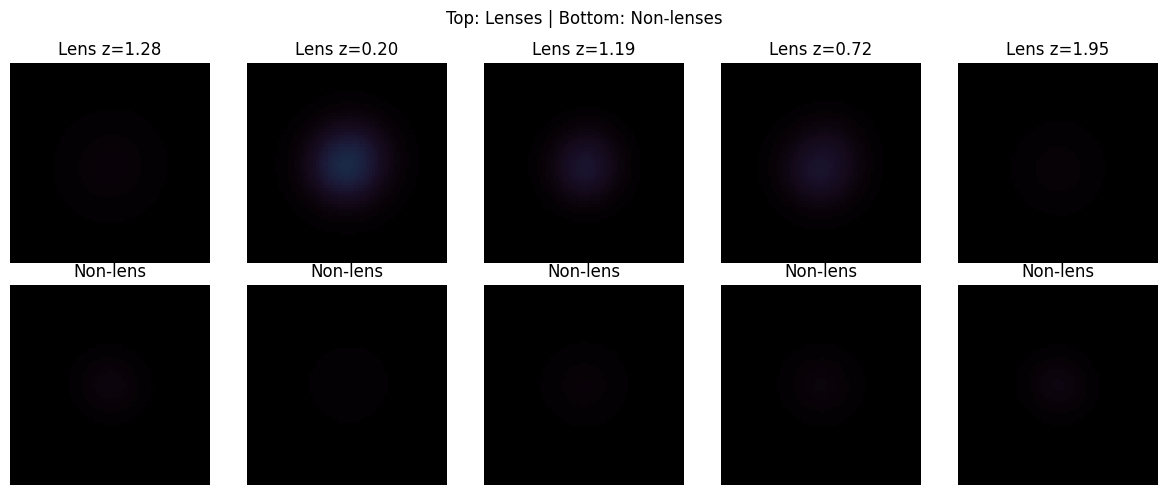

In [44]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    img = np.load(f'lens_project/testing_images/lens_{i:04d}.npy')
    axes[0, i].imshow(img, cmap='cubehelix', origin='lower', vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f'Lens z={df.iloc[i].source_redshift:.2f}')
    axes[0, i].axis('off')

for i in range(5):
    img = np.load(f'lens_project/testing_images/nonlens_{i:04d}.npy')
    axes[1, i].imshow(img, cmap='cubehelix', origin='lower', vmin=vmin, vmax=vmax)
    axes[1, i].set_title('Non-lens')
    axes[1, i].axis('off')

plt.suptitle('Top: Lenses | Bottom: Non-lenses')
plt.tight_layout()
plt.show()

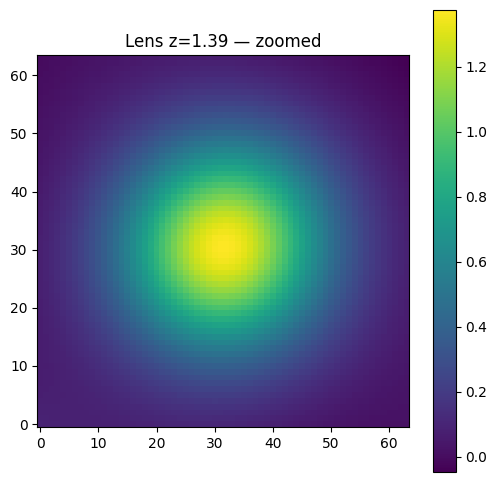

In [45]:
img = np.load('lens_project/testing_images/lens_0000.npy')
plt.figure(figsize=(6,6))
plt.imshow(img, cmap='viridis', origin='lower')
plt.colorbar()
plt.title(f"Lens z=1.39 — zoomed")
plt.show()

In [46]:
# Generate validation dataset
SAVE_DIR = 'lens_project'
os.makedirs(f'{SAVE_DIR}/validation_images', exist_ok=True)
N = 150  # 500 lens + 500 non-lens
metadata = []
print("Generating lens images...")
for i in range(N//2):  # random redshift — save but don't use yet
    #img, source_redshift = make_lens_image(seed=i)
    img, source_redshift = make_lens_image(seed=i , redshift_range= redshift_validation_range)
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    fname = f'lens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/validation_images/{fname}', degraded_lens)
    metadata.append({'filename': fname, 'label': 1, 'source_redshift': source_redshift})

print("Generating non-lens images...")
for i in range(N//2):
    img = make_non_lens_image(seed=i+10000)

    # FIX: Apply the exact same PSF degradation here!
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_non_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    
    fname = f'nonlens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/validation_images/{fname}', degraded_non_lens) # Save the degraded version
    metadata.append({'filename': fname, 'label': 0, 'source_redshift': None})

# Save metadata
df = pd.DataFrame(metadata)
df.to_csv(f'{SAVE_DIR}/validation_metadata.csv', index=False)
print(f"Done! {len(df)} images saved.")
print(df.head())

Generating lens images...
Generating non-lens images...
Done! 150 images saved.
        filename  label  source_redshift
0  lens_0000.npy      1         1.284974
1  lens_0001.npy      1         0.200206
2  lens_0002.npy      1         1.189392
3  lens_0003.npy      1         0.723629
4  lens_0004.npy      1         1.950832


In [47]:
# Generate training dataset
SAVE_DIR = 'lens_project'
os.makedirs(f'{SAVE_DIR}/training_images', exist_ok=True)
N = 800  # 500 lens + 500 non-lens
metadata = []
print("Generating lens images...")
for i in range(N//2):  # random redshift — save but don't use yet
    #img, source_redshift = make_lens_image(seed=i)
    img, source_redshift = make_lens_image(seed=i , redshift_range= redshift_train_range)
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    fname = f'lens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/training_images/{fname}', degraded_lens)
    metadata.append({'filename': fname, 'label': 1, 'source_redshift': source_redshift})

print("Generating non-lens images...")
for i in range(N//2):
    img = make_non_lens_image(seed=i+10000)
    
    # FIX: Apply the exact same PSF degradation here!
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_non_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    
    fname = f'nonlens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/training_images/{fname}', degraded_non_lens) # Save the degraded version
    metadata.append({'filename': fname, 'label': 0, 'source_redshift': None})

# Save metadata
df = pd.DataFrame(metadata)
df.to_csv(f'{SAVE_DIR}/training_metadata.csv', index=False)
print(f"Done! {len(df)} images saved.")
print(df.head())

Generating lens images...
Generating non-lens images...
Done! 800 images saved.
        filename  label  source_redshift
0  lens_0000.npy      1         0.441105
1  lens_0001.npy      1         0.200046
2  lens_0002.npy      1         0.419865
3  lens_0003.npy      1         0.316362
4  lens_0004.npy      1         0.589074


In [48]:
# Augment training set with additional high-z lens + matching non-lens images
N_AUG = 100
aug_metadata = []

print("Generating augmented high-z lens images...")
for i in range(N_AUG):
    seed = 20000 + i  # offset clear of existing seeds (0-399 lens, 10000-10399 nonlens)
    img, source_redshift = make_lens_image(seed=seed, redshift_range=(1.4, 2.2))
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    fname = f'auglens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/training_images/{fname}', degraded_lens)
    aug_metadata.append({'filename': fname, 'label': 1, 'source_redshift': source_redshift})

print("Generating matching non-lens images...")
for i in range(N_AUG):
    seed = 30000 + i  # separate offset range
    img = make_non_lens_image(seed=seed)
    
    # FIX: Apply the exact same PSF degradation here!
    random_seeing = np.random.uniform(0.6, 1.4) / pixel_scale 
    degraded_non_lens = apply_astropy_psf(img, seeing_fwhm_pix=random_seeing, profile='moffat')
    
    fname = f'augnonlens_{i:04d}.npy'
    np.save(f'{SAVE_DIR}/training_images/{fname}', degraded_non_lens) # Save the degraded version
    aug_metadata.append({'filename': fname, 'label': 0, 'source_redshift': None})

# Append to existing training metadata 
aug_df = pd.DataFrame(aug_metadata)
df = pd.concat([df, aug_df], ignore_index=True)
df.to_csv(f'{SAVE_DIR}/training_metadata.csv', index=False)
print(f"Training set now has {len(df)} images ({df.label.sum()} lens, {(df.label==0).sum()} non-lens)")

Generating augmented high-z lens images...
Generating matching non-lens images...
Training set now has 1000 images (500 lens, 500 non-lens)


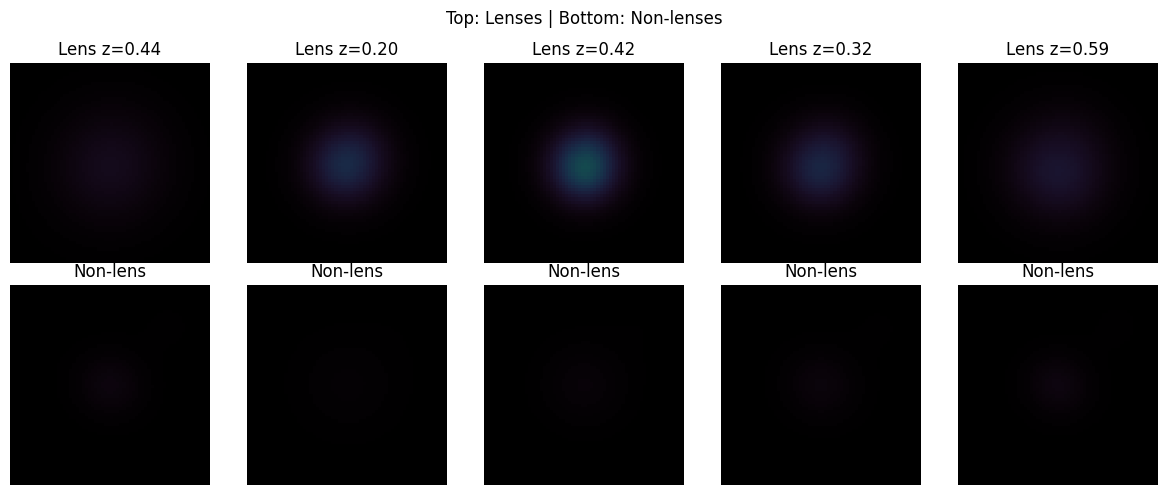

In [49]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    img = np.load(f'lens_project/training_images/lens_{i:04d}.npy')
    axes[0, i].imshow(img, cmap='cubehelix', origin='lower', vmin=vmin, vmax=vmax)
    axes[0, i].set_title(f'Lens z={df.iloc[i].source_redshift:.2f}')
    axes[0, i].axis('off')

for i in range(5):
    img = np.load(f'lens_project/training_images/nonlens_{i:04d}.npy')
    axes[1, i].imshow(img, cmap='cubehelix', origin='lower', vmin=vmin, vmax=vmax)
    axes[1, i].set_title('Non-lens')
    axes[1, i].axis('off')

plt.suptitle('Top: Lenses | Bottom: Non-lenses')
plt.tight_layout()
plt.show()

Original lens redshift range: 0.20 - 0.60
Augmented lens redshift range: 1.41 - 2.19
Combined training set: 500 lens images


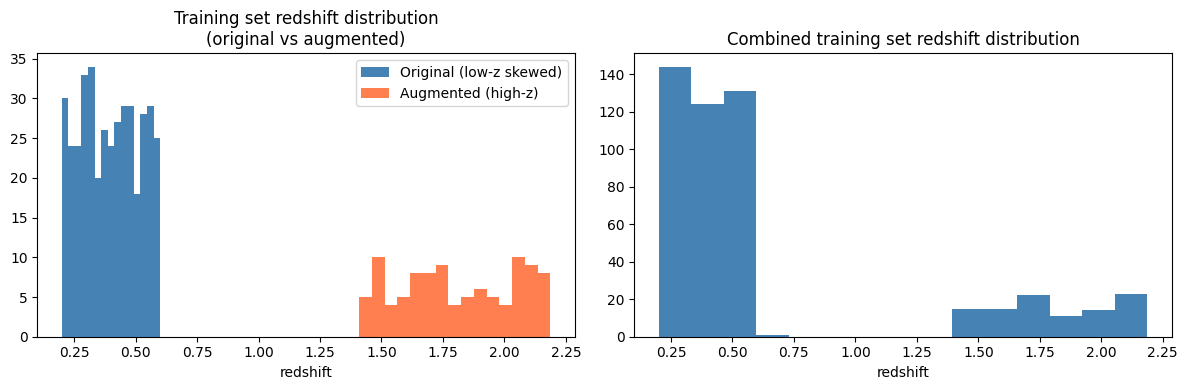

In [50]:
train_df = pd.read_csv(f'{SAVE_DIR}/training_metadata.csv')
train_lens = train_df[train_df.label == 1]

# Split out original vs augmented so you can see the effect distinctly
original_lens = train_lens[~train_lens.filename.str.startswith('auglens')]
augmented_lens = train_lens[train_lens.filename.str.startswith('auglens')]

print(f"Original lens redshift range: {original_lens.source_redshift.min():.2f} - {original_lens.source_redshift.max():.2f}")
print(f"Augmented lens redshift range: {augmented_lens.source_redshift.min():.2f} - {augmented_lens.source_redshift.max():.2f}")
print(f"Combined training set: {len(train_lens)} lens images")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: stacked view showing original vs augmented contribution
axes[0].hist(original_lens.source_redshift, bins=15, color='steelblue', label='Original (low-z skewed)')
axes[0].hist(augmented_lens.source_redshift, bins=15, color='coral', label='Augmented (high-z)')
axes[0].set_title('Training set redshift distribution\n(original vs augmented)')
axes[0].set_xlabel('redshift')
axes[0].legend()

# Right: combined view, same style as your original plot for direct comparison
axes[1].hist(train_lens.source_redshift, bins=15, color='steelblue')
axes[1].set_title('Combined training set redshift distribution')
axes[1].set_xlabel('redshift')

plt.tight_layout()
plt.show()
